# Medical Prediction Model Evaluation Toolkit

A comprehensive walkthrough of the evaluation framework from **Van Calster et al. (2025)**, *"Evaluation of performance measures in predictive AI models to support medical decisions"*, The Lancet Digital Health.

This notebook demonstrates all 32 performance measures across 5 domains, 7 visualization types, logistic recalibration, and bootstrap confidence intervals — using the ADNEX ovarian tumour prediction model as a case study.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Core evaluation
from medpred.evaluate import evaluate_model, evaluate_with_ci, results_to_dataframe

# Individual metric modules
from medpred.metrics.discrimination import discrimination_metrics, roc_curve_data, pr_curve_data
from medpred.metrics.calibration import calibration_metrics, logistic_recalibration, calibration_curve_data
from medpred.metrics.overall import overall_metrics
from medpred.metrics.classification import classification_metrics
from medpred.metrics.clinical_utility import clinical_utility_metrics, net_benefit_curve, expected_cost_curve

# Visualization
from medpred.visualization.plots import (
    plot_roc_curve, plot_pr_curve, plot_calibration,
    plot_risk_distribution, plot_decision_curve,
    plot_expected_cost_curve, plot_classification_at_thresholds,
    plot_full_evaluation,
)

# Data loading & bootstrap
from medpred.utils.data import load_case_study_data
from medpred.utils.bootstrap import bootstrap_ci

## 1. Load and explore the data

The ADNEX case study: external validation of the ADNEX model for predicting malignancy in women with an ovarian tumour (894 patients).

In [2]:
y_true, y_prob = load_case_study_data()

print(f"Patients:     {len(y_true)}")
print(f"Malignant:    {np.sum(y_true)} ({100*np.mean(y_true):.1f}%)")
print(f"Benign:       {np.sum(y_true == 0)} ({100*np.mean(y_true == 0):.1f}%)")
print(f"\nPredicted probabilities — min: {y_prob.min():.4f}, median: {np.median(y_prob):.4f}, max: {y_prob.max():.4f}")

Patients:     894
Malignant:    434 (48.5%)
Benign:       460 (51.5%)

Predicted probabilities — min: 0.0011, median: 0.2768, max: 0.9987


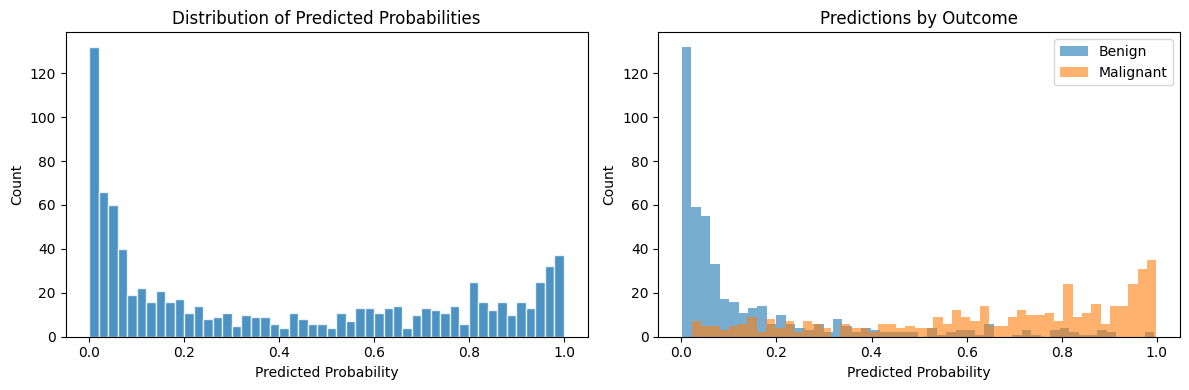

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_prob, bins=50, edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Predicted Probability")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Predicted Probabilities")

axes[1].hist(y_prob[y_true == 0], bins=50, alpha=0.6, label="Benign")
axes[1].hist(y_prob[y_true == 1], bins=50, alpha=0.6, label="Malignant")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Predictions by Outcome")
axes[1].legend()

plt.tight_layout()

## 2. Full model evaluation (one-liner)

`evaluate_model` computes all 32 metrics across the 5 performance domains in a single call.

**Decision threshold = 0.1** (10%) — accepting up to 9 false positives per true positive, appropriate for a cancer screening context.

In [4]:
results = evaluate_model(y_true, y_prob, threshold=0.1)

# Quick look at the structure
for domain, metrics in results.items():
    if domain == "meta":
        continue
    print(f"\n{domain.upper()} ({len(metrics)} metrics)")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:30s} {v:.4f}")
        else:
            print(f"  {k:30s} {v}")


DISCRIMINATION (3 metrics)
  auroc                          0.9114
  auprc                          0.8949
  pauroc                         0.8368

CALIBRATION (6 metrics)
  oe_ratio                       1.2281
  calibration_intercept          0.7530
  calibration_slope              0.9337
  eci                            0.0217
  ici                            0.1090
  ece                            0.0902

OVERALL (9 metrics)
  loglikelihood                  -370.0121
  logloss                        370.0121
  brier_score                    0.1326
  scaled_brier                   0.4693
  mcfadden_r2                    0.4025
  cox_snell_r2                   0.4275
  nagelkerke_r2                  0.5701
  discrimination_slope           0.5092
  mape                           0.2426

CLASSIFICATION (16 metrics)
  threshold                      0.1000
  tp                             414
  tn                             296
  fp                             164
  fn                 

### Results as a DataFrame

The `results_to_dataframe` function converts results into a table annotated with **properness** (can the measure be fooled by a non-ideal model?), **focus** (clear decision-analytical interpretation?), and the paper's **recommendation**.

In [5]:
df = results_to_dataframe(results)
df["value"] = df["value"].round(4)
df

,domain,measure,properness,focus,recommendation,value
0,discrimination,auroc,semi-proper,clear,Recommended,0.9114
1,discrimination,auprc,semi-proper,unclear,Inadvisable,0.8949
2,discrimination,pauroc,semi-proper,unclear,Inadvisable,0.8368
3,calibration,oe_ratio,semi-proper,clear,Not essential,1.2281
4,calibration,calibration_intercept,semi-proper,clear,Not essential,0.7530
5,calibration,calibration_slope,semi-proper,clear,Not essential,0.9337
6,calibration,eci,semi-proper,clear,Not essential,0.0217
7,calibration,ici,semi-proper,clear,Not essential,0.1090
8,calibration,ece,semi-proper,clear,Not essential,0.0902
9,overall,loglikelihood,strictly proper,clear,Not essential,-370.0121


## 3. Domain-by-domain deep dive

Each domain can also be computed individually using the lower-level metric functions.

### 3.1 Discrimination

Can the model distinguish between events and non-events? The paper **recommends AUROC** and considers AUPRC and pAUROC inadvisable.

In [6]:
disc = discrimination_metrics(y_true, y_prob, min_sensitivity=0.8)

for k, v in disc.items():
    tag = " ✓ Recommended" if k == "auroc" else " ✗ Inadvisable"
    print(f"  {k:10s} = {v:.4f}{tag}")

  auroc      = 0.9114 ✓ Recommended
  auprc      = 0.8949 ✗ Inadvisable
  pauroc     = 0.8368 ✗ Inadvisable


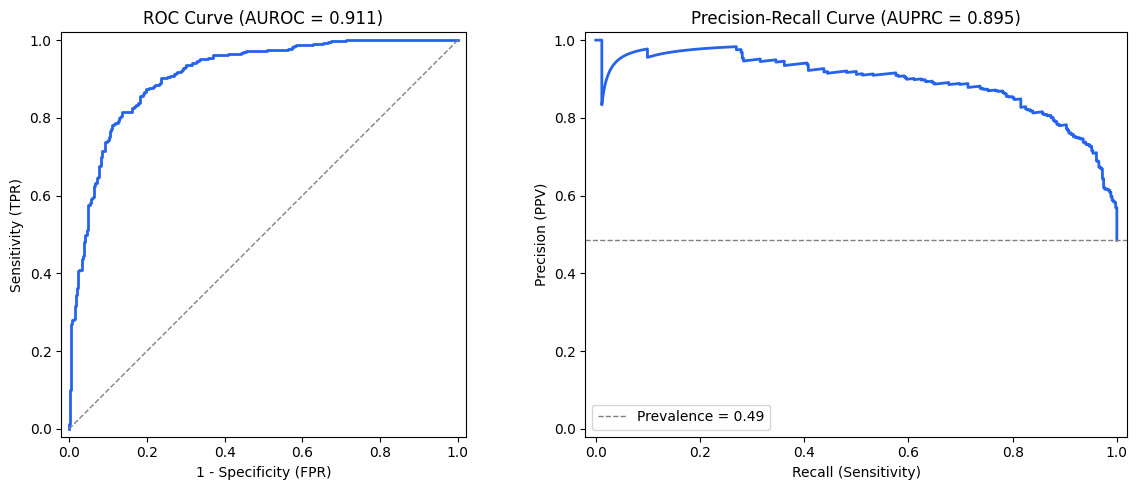

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_roc_curve(y_true, y_prob, auroc=disc["auroc"], ax=axes[0])
plot_pr_curve(y_true, y_prob, auprc=disc["auprc"], ax=axes[1])
plt.tight_layout()

### 3.2 Calibration

Do predicted probabilities match observed event rates? The paper **recommends the calibration plot** (visual assessment), not any single number.

In [8]:
cal = calibration_metrics(y_true, y_prob)

print("Calibration metrics (all semi-proper, clear focus):")
print(f"  O:E ratio             = {cal['oe_ratio']:.4f}  (ideal = 1.0)")
print(f"  Calibration intercept = {cal['calibration_intercept']:.4f}  (ideal = 0)")
print(f"  Calibration slope     = {cal['calibration_slope']:.4f}  (ideal = 1.0)")
print(f"  ECI                   = {cal['eci']:.4f}  (ideal = 0)")
print(f"  ICI                   = {cal['ici']:.4f}  (ideal = 0)")
print(f"  ECE                   = {cal['ece']:.4f}  (ideal = 0)")

Calibration metrics (all semi-proper, clear focus):
  O:E ratio             = 1.2281  (ideal = 1.0)
  Calibration intercept = 0.7530  (ideal = 0)
  Calibration slope     = 0.9337  (ideal = 1.0)
  ECI                   = 0.0217  (ideal = 0)
  ICI                   = 0.1090  (ideal = 0)
  ECE                   = 0.0902  (ideal = 0)


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Calibration Plot'}, xlabel='Estimated Probability', ylabel='Observed Proportion'>)

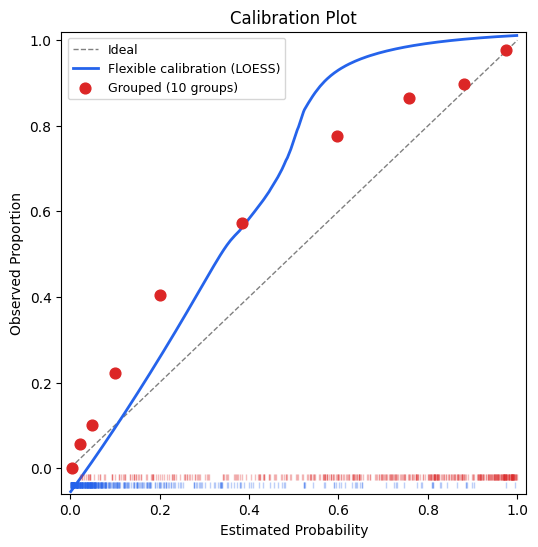

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_calibration(y_true, y_prob, ax=ax)

### 3.3 Overall performance

Composite measures that combine discrimination and calibration. Strictly proper measures (Brier, logloss) cannot be "fooled" — they are minimized only by the true probabilities.

In [10]:
overall = overall_metrics(y_true, y_prob)

print("Strictly proper:")
print(f"  Log-likelihood        = {overall['loglikelihood']:.4f}")
print(f"  Log loss              = {overall['logloss']:.4f}")
print(f"  Brier score           = {overall['brier_score']:.4f}")

print("\nAsymptotically strictly proper:")
print(f"  Scaled Brier          = {overall['scaled_brier']:.4f}")
print(f"  McFadden R²           = {overall['mcfadden_r2']:.4f}")
print(f"  Cox-Snell R²          = {overall['cox_snell_r2']:.4f}")
print(f"  Nagelkerke R²         = {overall['nagelkerke_r2']:.4f}")

print("\nImproper (inadvisable):")
print(f"  Discrimination slope  = {overall['discrimination_slope']:.4f}")
print(f"  MAPE                  = {overall['mape']:.4f}")

Strictly proper:
  Log-likelihood        = -370.0121
  Log loss              = 370.0121
  Brier score           = 0.1326

Asymptotically strictly proper:
  Scaled Brier          = 0.4693
  McFadden R²           = 0.4025
  Cox-Snell R²          = 0.4275
  Nagelkerke R²         = 0.5701

Improper (inadvisable):
  Discrimination slope  = 0.5092
  MAPE                  = 0.2426


### 3.4 Classification

Threshold-based measures. The paper notes that **all classification summary measures are improper** at clinically relevant thresholds. F1 is the only measure that is both improper **and** has unclear focus — making it the least recommended.

Sensitivity/specificity and PPV/NPV are acceptable when reported **descriptively as pairs**.

In [11]:
clf = classification_metrics(y_true, y_prob, threshold=0.1)

print(f"Threshold: {clf['threshold']}")
print(f"Confusion matrix: TP={clf['tp']}, FP={clf['fp']}, FN={clf['fn']}, TN={clf['tn']}")

print("\nDescriptive pairs:")
print(f"  Sensitivity = {clf['sensitivity']:.4f}   Specificity = {clf['specificity']:.4f}")
print(f"  PPV         = {clf['ppv']:.4f}   NPV         = {clf['npv']:.4f}")

print("\nSummary measures (all improper at clinical thresholds):")
for k in ["accuracy", "balanced_accuracy", "youden_index", "kappa", "mcc", "diagnostic_odds_ratio", "f1_score"]:
    print(f"  {k:25s} = {clf[k]:.4f}")

Threshold: 0.1
Confusion matrix: TP=414, FP=164, FN=20, TN=296

Descriptive pairs:
  Sensitivity = 0.9539   Specificity = 0.6435
  PPV         = 0.7163   NPV         = 0.9367

Summary measures (all improper at clinical thresholds):
  accuracy                  = 0.7942
  balanced_accuracy         = 0.7987
  youden_index              = 0.5974
  kappa                     = 0.5918
  mcc                       = 0.6246
  diagnostic_odds_ratio     = 37.3610
  f1_score                  = 0.8182


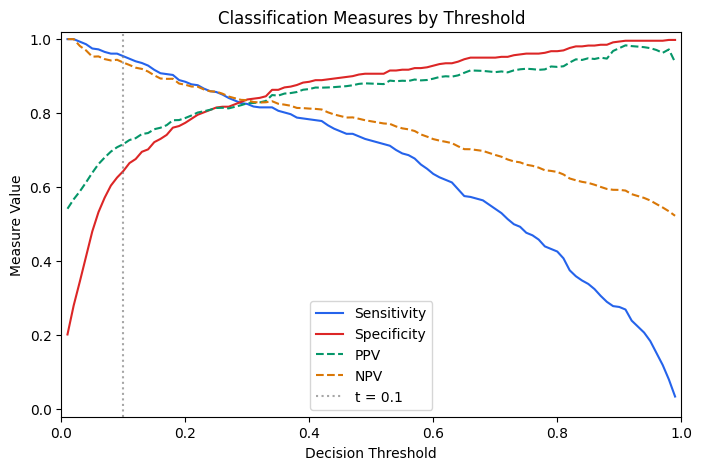

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_classification_at_thresholds(y_true, y_prob, ax=ax)
ax.axvline(x=0.1, color="gray", linestyle=":", alpha=0.7, label="t = 0.1")
ax.legend()

### 3.5 Clinical utility

The **most important domain** per the paper. Net benefit and expected cost incorporate misclassification costs, answering: *"Is this model better than treating all or treating none?"*

In [13]:
cu = clinical_utility_metrics(y_true, y_prob, threshold=0.1, cost_fn_ratio=0.9)

print("Recommended measures (all semi-proper, clear focus):")
print(f"  Net benefit (t=0.1)        = {cu['net_benefit']:.4f}  (max = prevalence = {cu['prevalence']:.4f})")
print(f"  Standardized NB (t=0.1)    = {cu['standardized_net_benefit']:.4f}  (max = 1.0)")
print(f"  Expected cost (cfn=0.9)    = {cu['expected_cost']:.4f}")
print(f"  Optimal EC threshold       = {cu['expected_cost_threshold']:.4f}")
print(f"\nReference strategies:")
print(f"  Treat-all NB (t=0.1)       = {cu['treat_all_nb']:.4f}")
print(f"  Treat-none NB              = {cu['treat_none_nb']:.4f}")

Recommended measures (all semi-proper, clear focus):
  Net benefit (t=0.1)        = 0.4427  (max = prevalence = 0.4855)
  Standardized NB (t=0.1)    = 0.9119  (max = 1.0)
  Expected cost (cfn=0.9)    = 0.0355
  Optimal EC threshold       = 0.0632

Reference strategies:
  Treat-all NB (t=0.1)       = 0.4283
  Treat-none NB              = 0.0000


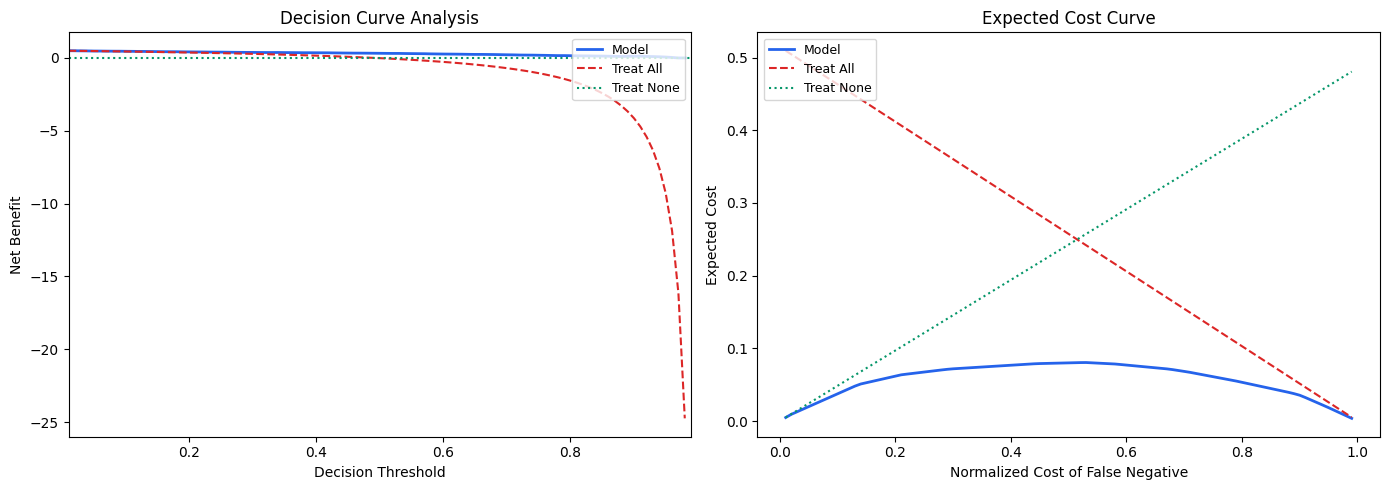

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_curve(y_true, y_prob, ax=axes[0])
plot_expected_cost_curve(y_true, y_prob, ax=axes[1])
plt.tight_layout()

## 4. Risk distribution

The paper **recommends** reporting risk distributions by outcome. This violin plot shows how predicted probabilities separate events from non-events.

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Risk Distribution by Outcome'}, ylabel='Estimated Probability'>)

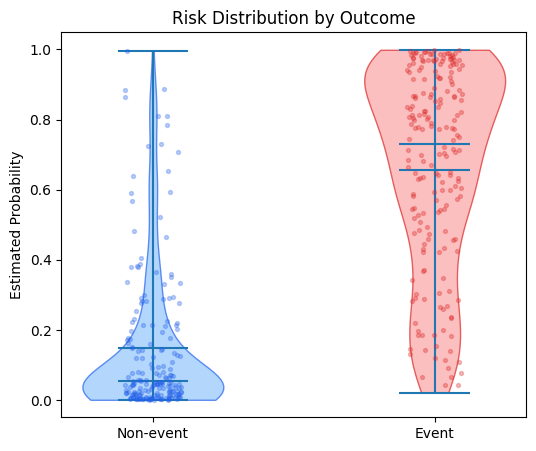

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_risk_distribution(y_true, y_prob, ax=ax)

## 5. Full evaluation panel

A single call generates all 6 recommended plots in a 2×3 grid.

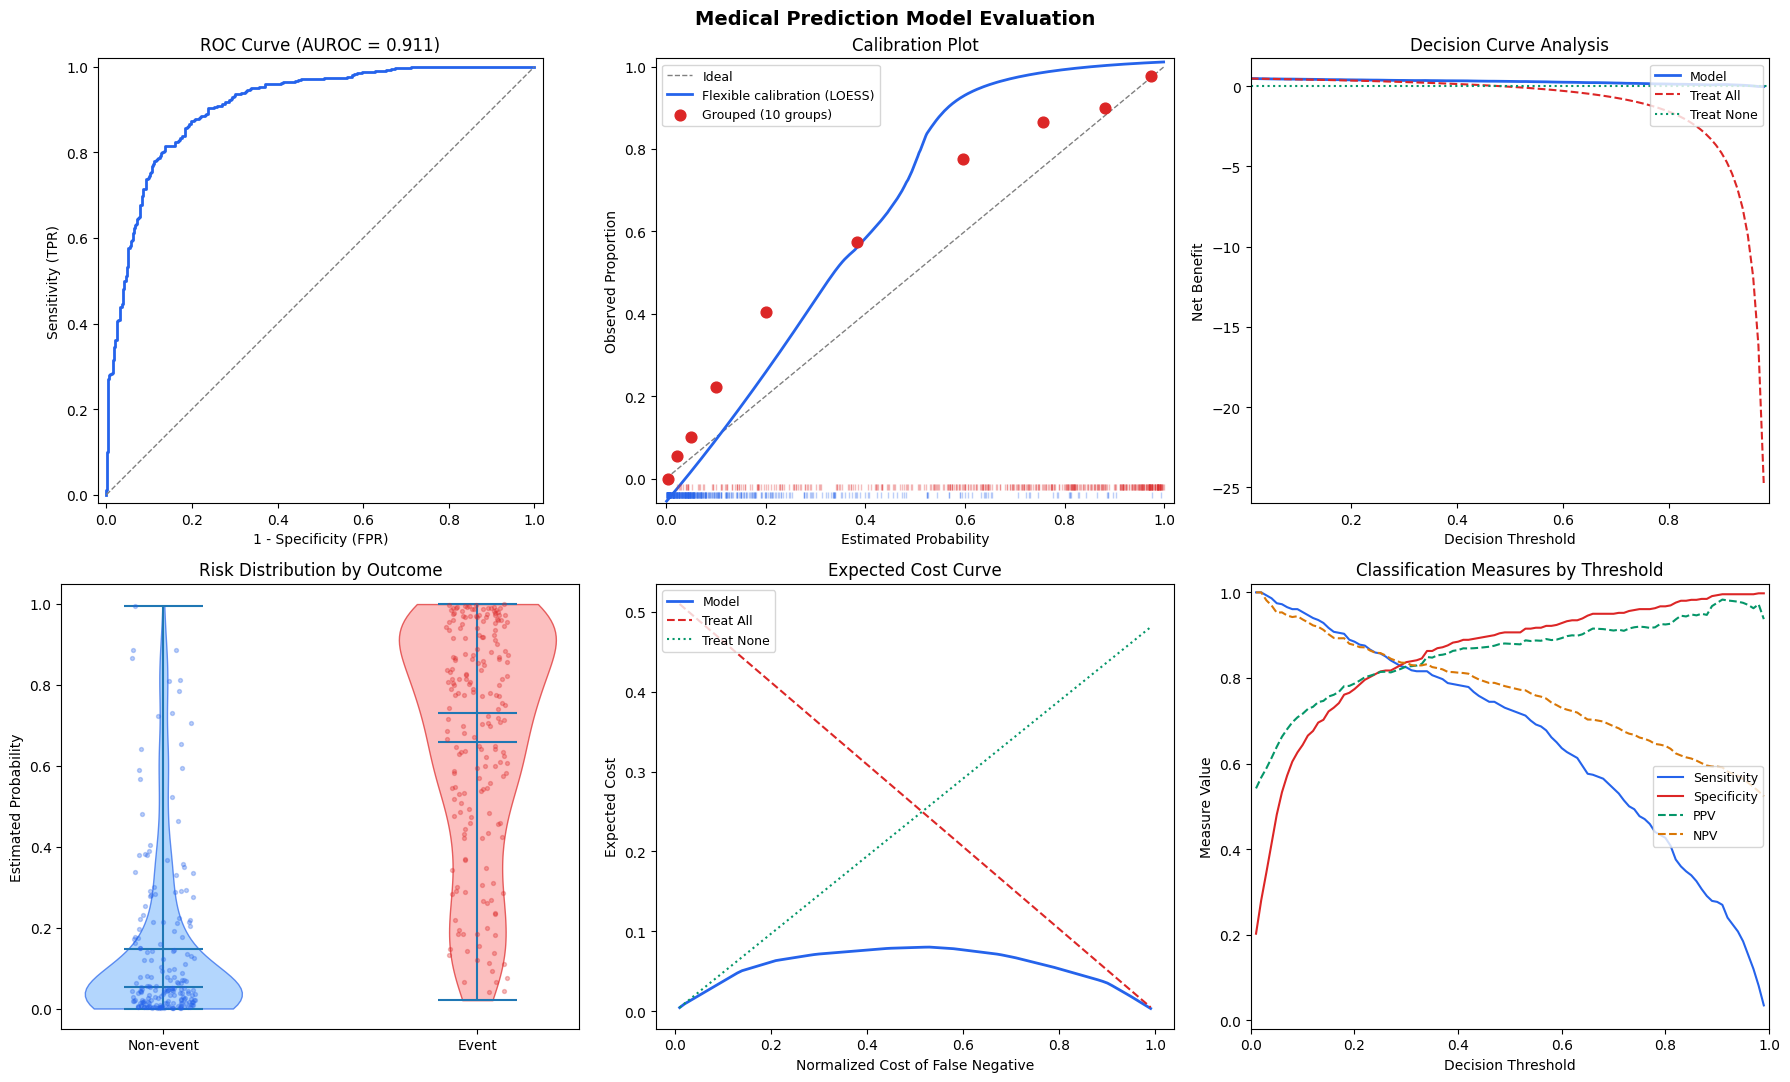

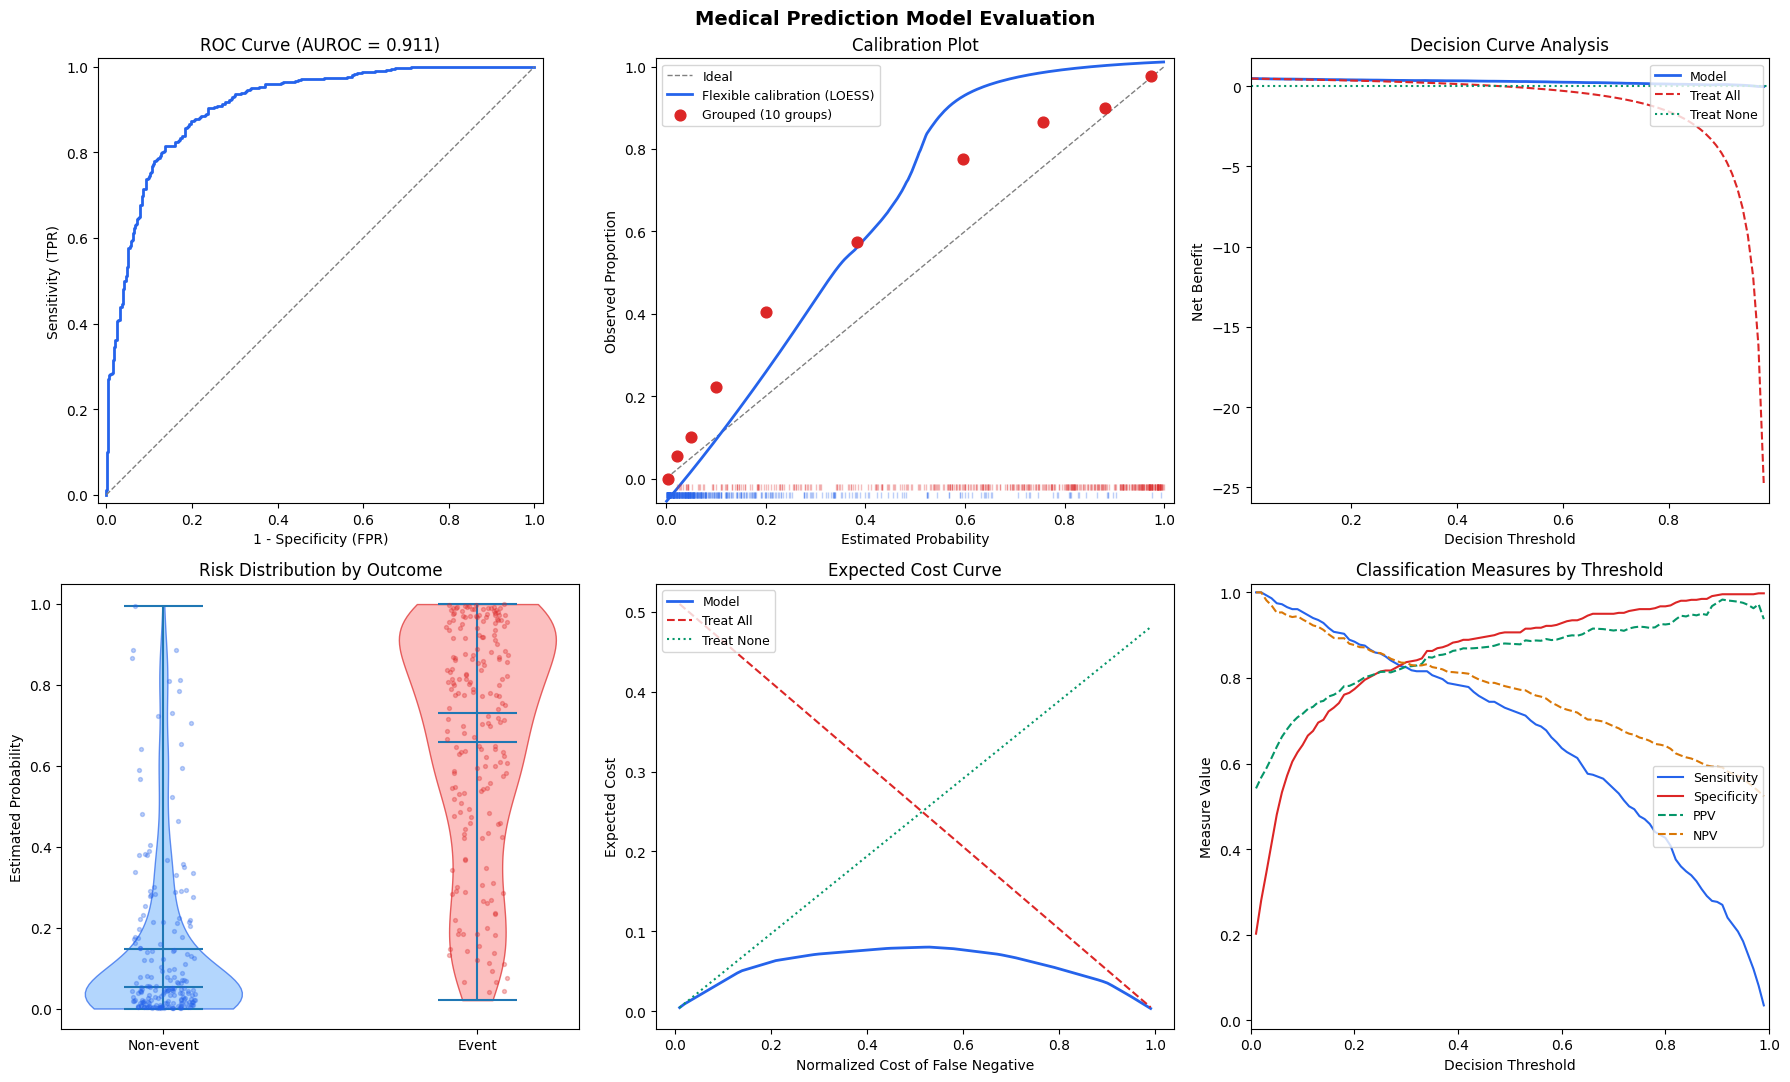

In [16]:
plot_full_evaluation(y_true, y_prob, auroc=results["discrimination"]["auroc"])

## 6. Logistic recalibration (Platt scaling)

Recalibration adjusts predicted probabilities to better match observed rates. It is **rank-preserving**, so discrimination (AUROC) stays the same while calibration improves.

In [17]:
y_prob_recal = logistic_recalibration(y_true, y_prob)
results_recal = evaluate_model(y_true, y_prob_recal, threshold=0.1)

# Compare key metrics before and after recalibration
comparison = pd.DataFrame({
    "Measure": ["AUROC", "O:E ratio", "Cal. intercept", "Cal. slope",
                "Brier score", "Net benefit (t=0.1)"],
    "Before": [
        results["discrimination"]["auroc"],
        results["calibration"]["oe_ratio"],
        results["calibration"]["calibration_intercept"],
        results["calibration"]["calibration_slope"],
        results["overall"]["brier_score"],
        results["clinical_utility"]["net_benefit"],
    ],
    "After": [
        results_recal["discrimination"]["auroc"],
        results_recal["calibration"]["oe_ratio"],
        results_recal["calibration"]["calibration_intercept"],
        results_recal["calibration"]["calibration_slope"],
        results_recal["overall"]["brier_score"],
        results_recal["clinical_utility"]["net_benefit"],
    ],
    "Ideal": ["higher", "1.0", "0", "1.0", "lower", "higher"],
})
comparison.round(4)

,Measure,Before,After,Ideal
0,AUROC,0.9114,0.9114,higher
1,O:E ratio,1.2281,1.0001,1.0
2,Cal. intercept,0.7530,0.0005,0
3,Cal. slope,0.9337,1.0001,1.0
4,Brier score,0.1326,0.1183,lower
5,Net benefit (t=0.1),0.4427,0.4442,higher


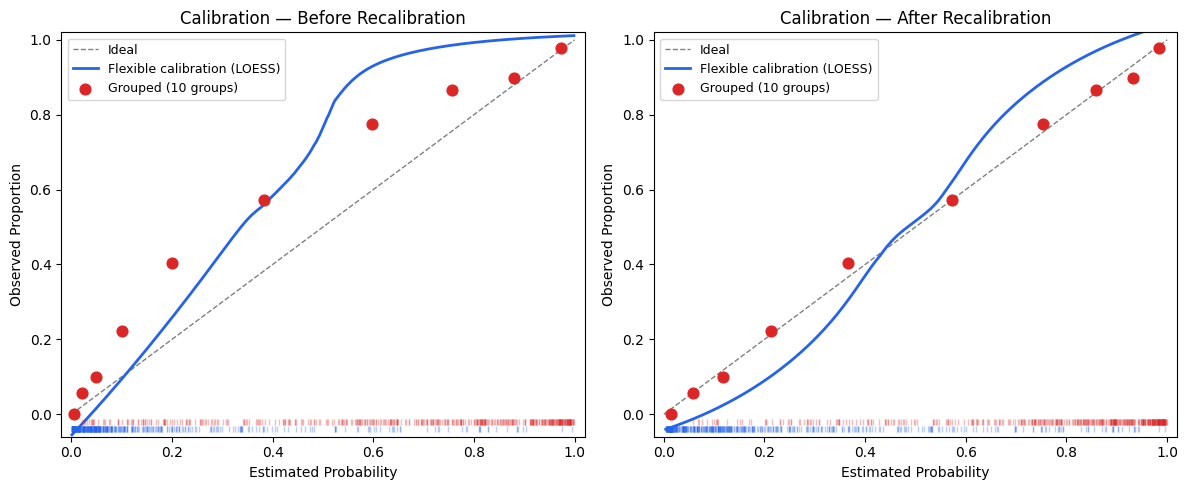

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_calibration(y_true, y_prob, ax=axes[0])
axes[0].set_title("Calibration — Before Recalibration")
plot_calibration(y_true, y_prob_recal, ax=axes[1])
axes[1].set_title("Calibration — After Recalibration")
plt.tight_layout()

## 7. Bootstrap confidence intervals

`evaluate_with_ci` wraps the full evaluation with percentile bootstrap confidence intervals.

In [19]:
results_ci = evaluate_with_ci(
    y_true, y_prob,
    threshold=0.1,
    n_bootstrap=500,  # use 1000+ for publication
    ci_level=0.95,
    random_state=42,
)

# Display key results with CIs
key_metrics = [
    ("discrimination", "auroc", "AUROC"),
    ("calibration", "oe_ratio", "O:E Ratio"),
    ("calibration", "calibration_intercept", "Cal. Intercept"),
    ("calibration", "calibration_slope", "Cal. Slope"),
    ("overall", "brier_score", "Brier Score"),
    ("overall", "scaled_brier", "Scaled Brier"),
    ("clinical_utility", "net_benefit", "Net Benefit"),
    ("clinical_utility", "standardized_net_benefit", "Std. Net Benefit"),
]

ci_rows = []
for domain, metric, label in key_metrics:
    v = results_ci[domain][metric]
    ci_rows.append({
        "Measure": label,
        "Point Estimate": round(v["point"], 4),
        "95% CI Lower": round(v["lower"], 4),
        "95% CI Upper": round(v["upper"], 4),
    })

pd.DataFrame(ci_rows)

,Measure,Point Estimate,95% CI Lower,95% CI Upper
0,AUROC,0.9114,0.8906,0.9283
1,O:E Ratio,1.2281,1.1681,1.2830
2,Cal. Intercept,0.7530,0.5571,0.9943
3,Cal. Slope,0.9337,0.8241,1.0546
4,Brier Score,0.1326,0.1180,0.1482
5,Scaled Brier,0.4693,0.4059,0.5274
6,Net Benefit,0.4427,0.4102,0.4741
7,Std. Net Benefit,0.9119,0.8884,0.9300


In [20]:
# Full results table with CIs
df_ci = results_to_dataframe(results_ci, with_ci=True)
df_ci.head(15)

,domain,measure,properness,focus,recommendation,value,ci_lower,ci_upper
0,discrimination,auroc,semi-proper,clear,Recommended,0.911385,0.890623,0.928268
1,discrimination,auprc,semi-proper,unclear,Inadvisable,0.894914,0.863722,0.922624
2,discrimination,pauroc,semi-proper,unclear,Inadvisable,0.836771,0.781726,0.880750
3,calibration,oe_ratio,semi-proper,clear,Not essential,1.228075,1.168096,1.283049
4,calibration,calibration_intercept,semi-proper,clear,Not essential,0.753006,0.557109,0.994342
5,calibration,calibration_slope,semi-proper,clear,Not essential,0.933651,0.824060,1.054553
6,calibration,eci,semi-proper,clear,Not essential,0.021712,0.012340,0.028633
7,calibration,ici,semi-proper,clear,Not essential,0.108974,0.085945,0.123996
8,calibration,ece,semi-proper,clear,Not essential,0.090158,0.072554,0.114004
9,overall,loglikelihood,strictly proper,clear,Not essential,-370.012142,-409.016925,-332.598195


## 8. Lower-level API: bootstrap a single domain, access raw curve data

You can bootstrap any single metric module directly, and all curve functions return raw arrays for custom plotting.

In [21]:
# Bootstrap just the discrimination metrics
disc_ci = bootstrap_ci(
    y_true, y_prob,
    metric_fn=discrimination_metrics,
    n_bootstrap=500,
    ci_level=0.95,
    random_state=42,
    min_sensitivity=0.8,
)

for metric, val in disc_ci.items():
    print(f"  {metric:10s}: {val['point']:.4f}  (95% CI: {val['lower']:.4f} – {val['upper']:.4f})")

  auroc     : 0.9114  (95% CI: 0.8906 – 0.9283)
  auprc     : 0.8949  (95% CI: 0.8637 – 0.9226)
  pauroc    : 0.8368  (95% CI: 0.7817 – 0.8808)


In [22]:
# ROC and PR curve data
roc = roc_curve_data(y_true, y_prob)
pr = pr_curve_data(y_true, y_prob)

print(f"ROC curve: {len(roc['fpr'])} points")
print(f"PR curve:  {len(pr['precision'])} points")

# Calibration curve data
cal_curve = calibration_curve_data(y_true, y_prob, n_groups=10)
print(f"\nGrouped calibration ({len(cal_curve['grouped_pred'])} groups):")
for p, o in zip(cal_curve["grouped_pred"], cal_curve["grouped_obs"]):
    print(f"  predicted={p:.3f}  observed={o:.3f}")

ROC curve: 212 points
PR curve:  890 points

Grouped calibration (10 groups):
  predicted=0.005  observed=0.000
  predicted=0.022  observed=0.056
  predicted=0.049  observed=0.100
  predicted=0.100  observed=0.222
  predicted=0.201  observed=0.404
  predicted=0.384  observed=0.573
  predicted=0.597  observed=0.775
  predicted=0.757  observed=0.865
  predicted=0.881  observed=0.899
  predicted=0.974  observed=0.978


In [23]:
# Net benefit and expected cost curve data
nb = net_benefit_curve(y_true, y_prob)
ec = expected_cost_curve(y_true, y_prob)

print(f"Net benefit curve: {len(nb['thresholds'])} thresholds")
print(f"Expected cost curve: {len(ec['cost_ratios'])} cost ratios")

Net benefit curve: 99 thresholds
Expected cost curve: 99 cost ratios


## 9. Paper recommendations summary

| What to report | Why |
|---|---|
| **AUROC** | Best single discrimination measure (semi-proper, clear focus) |
| **Calibration plot** | Visual assessment captures nuances no single number can |
| **Net benefit / decision curve** | Shows clinical utility across thresholds |
| **Risk distributions** | Reveals how the model behaves for events vs non-events |

| What to avoid | Why |
|---|---|
| **F1 score** | Only measure that is both *improper* and has *unclear focus* |
| **AUPRC** | Unclear decision-analytical focus |
| **Accuracy** at clinical thresholds | Improper — can be optimized by a non-ideal model |